<a href="https://colab.research.google.com/github/mawang7787-sketch/AIFFEL_quest_rs/blob/main/Exploration/Quest03/data_augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!wget "http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar" -P ~/work/data_augmentation/data/
!tar -xf ~/work/data_augmentation/data/images.tar -C ~/work/data_augmentation/data/

--2026-06-10 03:44:08--  http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar
Resolving vision.stanford.edu (vision.stanford.edu)... 171.64.68.10
Connecting to vision.stanford.edu (vision.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 793579520 (757M) [application/x-tar]
Saving to: ‘/root/work/data_augmentation/data/images.tar’

images.tar          100%[===================>] 756.82M  66.2MB/s    in 9.0s    

2026-06-10 03:44:17 (83.7 MB/s) - ‘/root/work/data_augmentation/data/images.tar’ saved [793579520/793579520]



In [ ]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms

dataset_dir = "/root/work/data_augmentation/data/Images/"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

full_dataset = ImageFolder(root=dataset_dir, transform=transform)

total_size = len(full_dataset)
train_size = int(0.583 * total_size)   # 약 12,000장
test_size = total_size - train_size     # 약 8,580장
ds_train, ds_test = random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(ds_train, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(ds_test, batch_size=32, shuffle=False, num_workers=0)

ds_info = {
    "num_classes": len(full_dataset.classes),
    "class_names": full_dataset.classes
}
print(f"전체: {total_size}장 / train: {train_size} / test: {test_size}")
print(f"클래스 수: {ds_info['num_classes']}")

전체: 20580장 / train: 11998 / test: 8582
클래스 수: 120


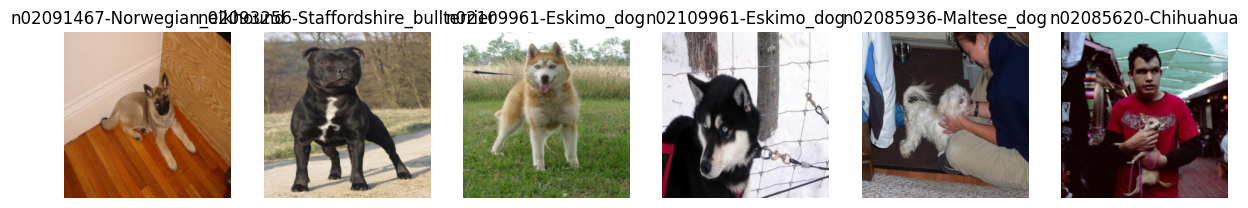

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def show_examples(data_loader, class_names, num_images=6):
    data_iter = iter(data_loader)
    images, labels = next(data_iter)

    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    for i in range(num_images):
        image = images[i].permute(1, 2, 0).numpy()  # (C,H,W)→(H,W,C)
        image = (image * 0.5) + 0.5                  # 정규화 복원
        image = np.clip(image, 0, 1)
        axes[i].imshow(image)
        axes[i].axis('off')
        axes[i].set_title(class_names[labels[i].item()])
    plt.show()

show_examples(train_loader, ds_info["class_names"])

In [ ]:
# 기본 전처리 (resize + normalize) — 모든 데이터 공통
def normalize_and_resize_img():
    return transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])

# 기본 augmentation — 좌우반전 + 밝기 변화
def augment():
    return transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),  # 50% 확률 좌우반전
        transforms.ColorJitter(brightness=0.2)   # 밝기 ±20% 변화
    ])

print("함수 정의 완료")

함수 정의 완료


In [ ]:
# 데이터셋에 전처리/augmentation 적용 후 DataLoader 반환
def apply_normalize_on_dataset(dataset, is_test=False, batch_size=16, with_aug=False):
    transform = normalize_and_resize_img()

    # train이고 aug 옵션이 켜졌을 때만 augmentation 추가
    if not is_test and with_aug:
        dataset.dataset.transform = transforms.Compose([
            *augment().transforms,
            *transform.transforms
        ])
    else:
        dataset.dataset.transform = transform

    # test는 셔플 안 함
    return DataLoader(dataset, batch_size=batch_size, shuffle=not is_test, num_workers=0)

print("완료")

완료


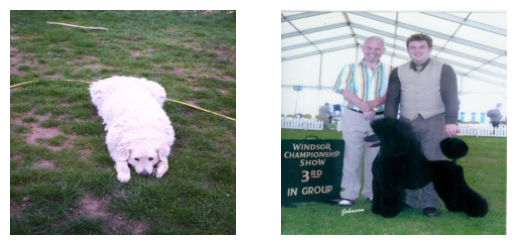

In [ ]:
import matplotlib.pyplot as plt

# augmentation 없는 데이터로더 준비 (CutMix 실험용)
ds_train_no_aug = apply_normalize_on_dataset(ds_train, with_aug=False)

# 배치에서 이미지 2장 꺼내기
data_iter = iter(ds_train_no_aug)
images, labels = next(data_iter)

image_a = images[0].permute(1, 2, 0).numpy()  # 첫 번째 이미지
image_b = images[1].permute(1, 2, 0).numpy()  # 두 번째 이미지
label_a = labels[0].item()
label_b = labels[1].item()

# 정규화 복원해서 확인
image_a = (image_a * 0.5) + 0.5
image_b = (image_b * 0.5) + 0.5

plt.subplot(1, 2, 1); plt.imshow(image_a); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(image_b); plt.axis('off')
plt.show()

In [ ]:
def get_clip_box(image_a, image_b):
    # 이미지 크기 (numpy는 H,W,C 순서)
    image_size_x = image_a.shape[1]  # 가로
    image_size_y = image_a.shape[0]  # 세로

    # 박스 중심점 랜덤 선택
    x = np.random.randint(0, image_size_x)
    y = np.random.randint(0, image_size_y)

    # 박스 크기 (면적이 랜덤하게 정해지도록)
    width = int(image_size_x * np.sqrt(1 - np.random.rand()))
    height = int(image_size_y * np.sqrt(1 - np.random.rand()))

    # 박스의 좌상단~우하단 좌표 (이미지 밖으로 안 나가게 제한)
    x_min = max(0, x - width // 2)
    y_min = max(0, y - height // 2)
    x_max = min(image_size_x, x + width // 2)
    y_max = min(image_size_y, y + height // 2)

    return x_min, y_min, x_max, y_max

x_min, y_min, x_max, y_max = get_clip_box(image_a, image_b)
print('x:', x_min, x_max)
print('y:', y_min, y_max)

x: 73 224
y: 44 224


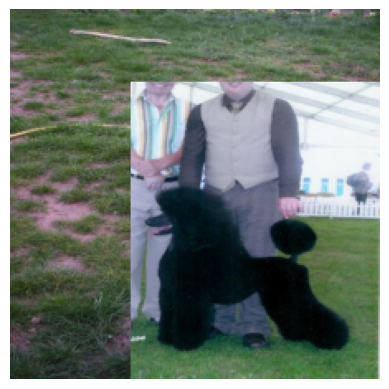

In [ ]:
def mix_2_images(image_a, image_b, x_min, y_min, x_max, y_max):
    # image_a를 복사해서 시작 (원본 보존)
    mixed = image_a.copy()
    # 박스 영역만 image_b로 덮어쓰기
    mixed[y_min:y_max, x_min:x_max, :] = image_b[y_min:y_max, x_min:x_max, :]
    return mixed

mixed_img = mix_2_images(image_a, image_b, x_min, y_min, x_max, y_max)

plt.imshow(mixed_img)
plt.axis('off')
plt.show()

In [ ]:
import torch
import torch.nn.functional as F

def mix_2_labels(label_a, label_b, x_min, y_min, x_max, y_max,
                 image_size_x, image_size_y, num_classes=120):
    # 박스 면적이 전체에서 차지하는 비율
    mixed_area = (x_max - x_min) * (y_max - y_min)
    total_area = image_size_x * image_size_y
    ratio = mixed_area / total_area

    # 라벨을 원-핫 벡터로 변환
    label_a = F.one_hot(torch.tensor(label_a), num_classes=num_classes).float()
    label_b = F.one_hot(torch.tensor(label_b), num_classes=num_classes).float()

    # 면적 비율대로 섞기 (박스만큼 b, 나머지 a)
    mixed_label = (1 - ratio) * label_a + ratio * label_b
    return mixed_label

mixed_label = mix_2_labels(label_a, label_b, x_min, y_min, x_max, y_max,
                           image_a.shape[1], image_a.shape[0])
print("섞인 라벨에서 0이 아닌 값:")
print(mixed_label[mixed_label > 0])

섞인 라벨에서 0이 아닌 값:
tensor([0.4583, 0.5417])


In [ ]:
def cutmix(images, labels, num_classes=120):
    # 텐서를 numpy로 (우리 함수들이 numpy 기준이라)
    images_np = images.permute(0, 2, 3, 1).numpy()  # (B,C,H,W)→(B,H,W,C)
    labels_np = labels.numpy()

    batch_size = len(images_np)
    mixed_imgs = []
    mixed_labels = []

    for i in range(batch_size):
        image_a = images_np[i]
        label_a = labels_np[i]

        # 배치 안에서 섞을 짝(다른 이미지) 랜덤 선택
        j = np.random.randint(0, batch_size)
        image_b = images_np[j]
        label_b = labels_np[j]

        # 박스 정하고 → 이미지 섞고 → 라벨 섞기
        x_min, y_min, x_max, y_max = get_clip_box(image_a, image_b)
        mixed_img = mix_2_images(image_a, image_b, x_min, y_min, x_max, y_max)
        mixed_label = mix_2_labels(label_a, label_b, x_min, y_min, x_max, y_max,
                                   image_a.shape[1], image_a.shape[0], num_classes)

        mixed_imgs.append(mixed_img)
        mixed_labels.append(mixed_label)

    # 다시 텐서로 (B,H,W,C)→(B,C,H,W)
    mixed_imgs = torch.tensor(np.array(mixed_imgs)).permute(0, 3, 1, 2).float()
    mixed_labels = torch.stack(mixed_labels)
    return mixed_imgs, mixed_labels

# 테스트
test_imgs, test_labels = cutmix(images, labels)
print("섞인 이미지 shape:", test_imgs.shape)
print("섞인 라벨 shape:", test_labels.shape)

섞인 이미지 shape: torch.Size([16, 3, 224, 224])
섞인 라벨 shape: torch.Size([16, 120])


In [ ]:
def mixup(images, labels, num_classes=120):
    images_np = images.permute(0, 2, 3, 1).numpy()
    labels_np = labels.numpy()

    batch_size = len(images_np)
    mixed_imgs = []
    mixed_labels = []

    for i in range(batch_size):
        image_a = images_np[i]
        label_a = labels_np[i]

        # 섞을 짝 랜덤 선택
        j = np.random.randint(0, batch_size)
        image_b = images_np[j]
        label_b = labels_np[j]

        # 섞는 비율 랜덤 (0~1)
        ratio = np.random.rand()

        # 이미지 전체를 비율대로 겹치기 (CutMix는 잘라붙이기, MixUp은 통째 혼합)
        mixed_img = (1 - ratio) * image_a + ratio * image_b

        # 라벨도 같은 비율로
        label_a_oh = F.one_hot(torch.tensor(label_a), num_classes=num_classes).float()
        label_b_oh = F.one_hot(torch.tensor(label_b), num_classes=num_classes).float()
        mixed_label = (1 - ratio) * label_a_oh + ratio * label_b_oh

        mixed_imgs.append(mixed_img)
        mixed_labels.append(mixed_label)

    mixed_imgs = torch.tensor(np.array(mixed_imgs)).permute(0, 3, 1, 2).float()
    mixed_labels = torch.stack(mixed_labels)
    return mixed_imgs, mixed_labels

# 테스트
test_imgs, test_labels = mixup(images, labels)
print("섞인 이미지 shape:", test_imgs.shape)
print("섞인 라벨 shape:", test_labels.shape)

섞인 이미지 shape: torch.Size([16, 3, 224, 224])
섞인 라벨 shape: torch.Size([16, 120])


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


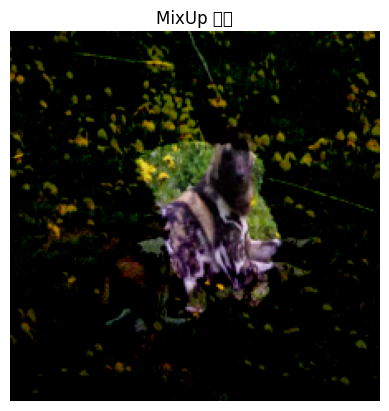

In [ ]:
# MixUp 결과 한 장 시각화
sample = test_imgs[0].permute(1, 2, 0).numpy()
sample = np.clip(sample, 0, 1)
plt.imshow(sample)
plt.axis('off')
plt.title("MixUp 결과")
plt.show()

In [ ]:
import torch.nn as nn
import torchvision.models as models

num_classes = len(ds_info["class_names"])  # 120

# aug 없이 학습할 ResNet50
resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
resnet50.fc = nn.Linear(resnet50.fc.in_features, num_classes)  # 출력층 1000→120 교체

# aug 적용해 학습할 ResNet50 (같은 구조 하나 더)
aug_resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
aug_resnet50.fc = nn.Linear(aug_resnet50.fc.in_features, num_classes)

print("모델 2개 준비 완료")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 196MB/s]


모델 2개 준비 완료


In [ ]:
# aug 없는 학습 데이터
ds_train_no_aug = apply_normalize_on_dataset(ds_train, with_aug=False)
# aug 있는 학습 데이터
ds_train_aug = apply_normalize_on_dataset(ds_train, with_aug=True)
# test 데이터 (aug 없음, 셔플 없음)
ds_test_loader = apply_normalize_on_dataset(ds_test, is_test=True)

print("데이터로더 3개 준비 완료")

데이터로더 3개 준비 완료


In [ ]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train(model, train_loader, test_loader, epochs=3):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

    history = {'val_accuracy': []}

    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        # 검증
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
        val_acc = 100. * correct / total
        history['val_accuracy'].append(val_acc)
        print(f"Epoch {epoch+1}/{epochs} | val_acc: {val_acc:.2f}%")

    return history

In [ ]:
print("=== aug 없이 학습 ===")
history_no_aug = train(resnet50, ds_train_no_aug, ds_test_loader, epochs=3)

=== aug 없이 학습 ===
Epoch 1/3 | val_acc: 77.02%
Epoch 2/3 | val_acc: 80.70%
Epoch 3/3 | val_acc: 80.07%


In [ ]:
print("=== aug 적용해 학습 ===")
history_aug = train(aug_resnet50, ds_train_aug, ds_test_loader, epochs=3)

=== aug 적용해 학습 ===
Epoch 1/3 | val_acc: 77.06%
Epoch 2/3 | val_acc: 78.22%
Epoch 3/3 | val_acc: 79.85%


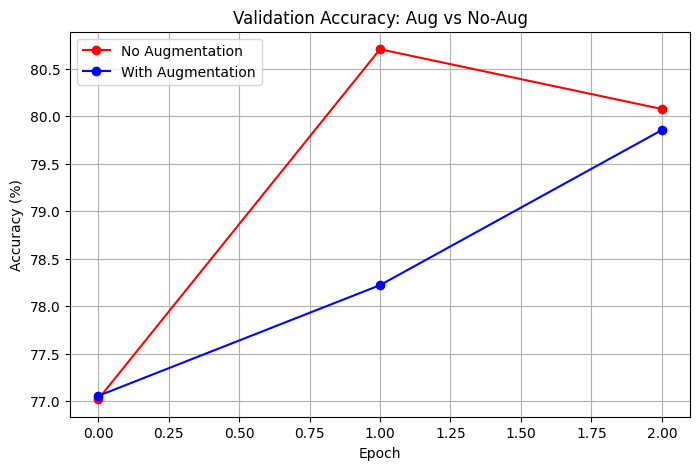

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history_no_aug['val_accuracy'], 'r-o', label='No Augmentation')
plt.plot(history_aug['val_accuracy'], 'b-o', label='With Augmentation')
plt.title('Validation Accuracy: Aug vs No-Aug')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import torch.optim as optim

def train_with_mix(model, train_loader, test_loader, mix_fn, epochs=3):
    model.to(device)
    optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

    history = {'val_accuracy': []}

    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            # MixUp 또는 CutMix 적용 (soft label 반환)
            images, soft_labels = mix_fn(images, labels)
            images, soft_labels = images.to(device), soft_labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            # soft label용 loss: -sum(soft_label * log_softmax(output))
            log_probs = nn.functional.log_softmax(outputs, dim=1)
            loss = -(soft_labels * log_probs).sum(dim=1).mean()
            loss.backward()
            optimizer.step()

        # 검증 (test는 일반 라벨이라 기존 방식)
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
        val_acc = 100. * correct / total
        history['val_accuracy'].append(val_acc)
        print(f"Epoch {epoch+1}/{epochs} | val_acc: {val_acc:.2f}%")

    return history

In [ ]:
# CutMix 학습용 모델
cutmix_resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
cutmix_resnet50.fc = nn.Linear(cutmix_resnet50.fc.in_features, num_classes)

print("=== CutMix 적용 학습 ===")
history_cutmix = train_with_mix(cutmix_resnet50, ds_train_no_aug, ds_test_loader, cutmix, epochs=3)

=== CutMix 적용 학습 ===
Epoch 1/3 | val_acc: 72.24%
Epoch 2/3 | val_acc: 76.80%
Epoch 3/3 | val_acc: 79.50%


In [ ]:
mixup_resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
mixup_resnet50.fc = nn.Linear(mixup_resnet50.fc.in_features, num_classes)

print("=== MixUp 적용 학습 ===")
history_mixup = train_with_mix(mixup_resnet50, ds_train_no_aug, ds_test_loader, mixup, epochs=3)

=== MixUp 적용 학습 ===
Epoch 1/3 | val_acc: 67.36%
Epoch 2/3 | val_acc: 77.65%
Epoch 3/3 | val_acc: 77.70%


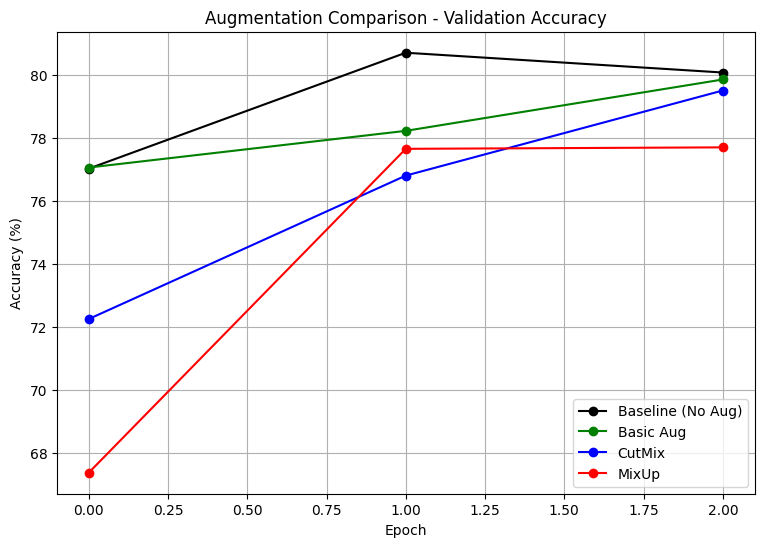

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))
plt.plot(history_no_aug['val_accuracy'], 'k-o', label='Baseline (No Aug)')
plt.plot(history_aug['val_accuracy'], 'g-o', label='Basic Aug')
plt.plot(history_cutmix['val_accuracy'], 'b-o', label='CutMix')
plt.plot(history_mixup['val_accuracy'], 'r-o', label='MixUp')
plt.title('Augmentation Comparison - Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()

학습 LMS에서 주어진 Stanford Dogs로 기본 Augmentation, CutMix, MixUp을 직접 구현하고 ResNet50(pretrained)으로 비교 학습했다

CutMix(잘라붙이기)와 MixUp(반투명 겹치기)을 직접 만들어 차이점을 보았다 이미지뿐 아니라 라벨도 섞은 비율대로(soft label) 바뀌는 게 핵심

비교 결과: 3 epoch 기준 baseline(80%) > 기본aug(79.8%) > CutMix(79.5%) > MixUp(77.7%)

증강 기법일수록 초반 정확도는 낮지만 상승 폭이 가팔랐다 → 증강은 데이터를 어렵게 만들어 초반엔 손해지만, 오래 학습하면 일반화로 따라잡는다

아쉬운점으로는 3 epoch는 증강 효과가 드러나기엔 짧았다 → baseline이 앞선 건 학습 부족이 이유

시간 단축의 이유로 선택한 pretrained이기에 baseline부터 높아 증강 효과가 끼어들 여지가 적었다